<img src='https://www.unifor.br/o/unifor-theme/images/unifor-logo-horizontal.svg' width="100px"><br>
Universidade de Fortaleza

## X500 - Introdução a Ciência de dados

________________________________
*Prof.* Erneson Alves de Oliveira<br>
*Alunos:* José Freitas Alves Neto | Isaque Gadelha | Ricardo Alexandre<br>
<br>

# Pergunta Norteadora: a altura importa para os jogadores da NBA?

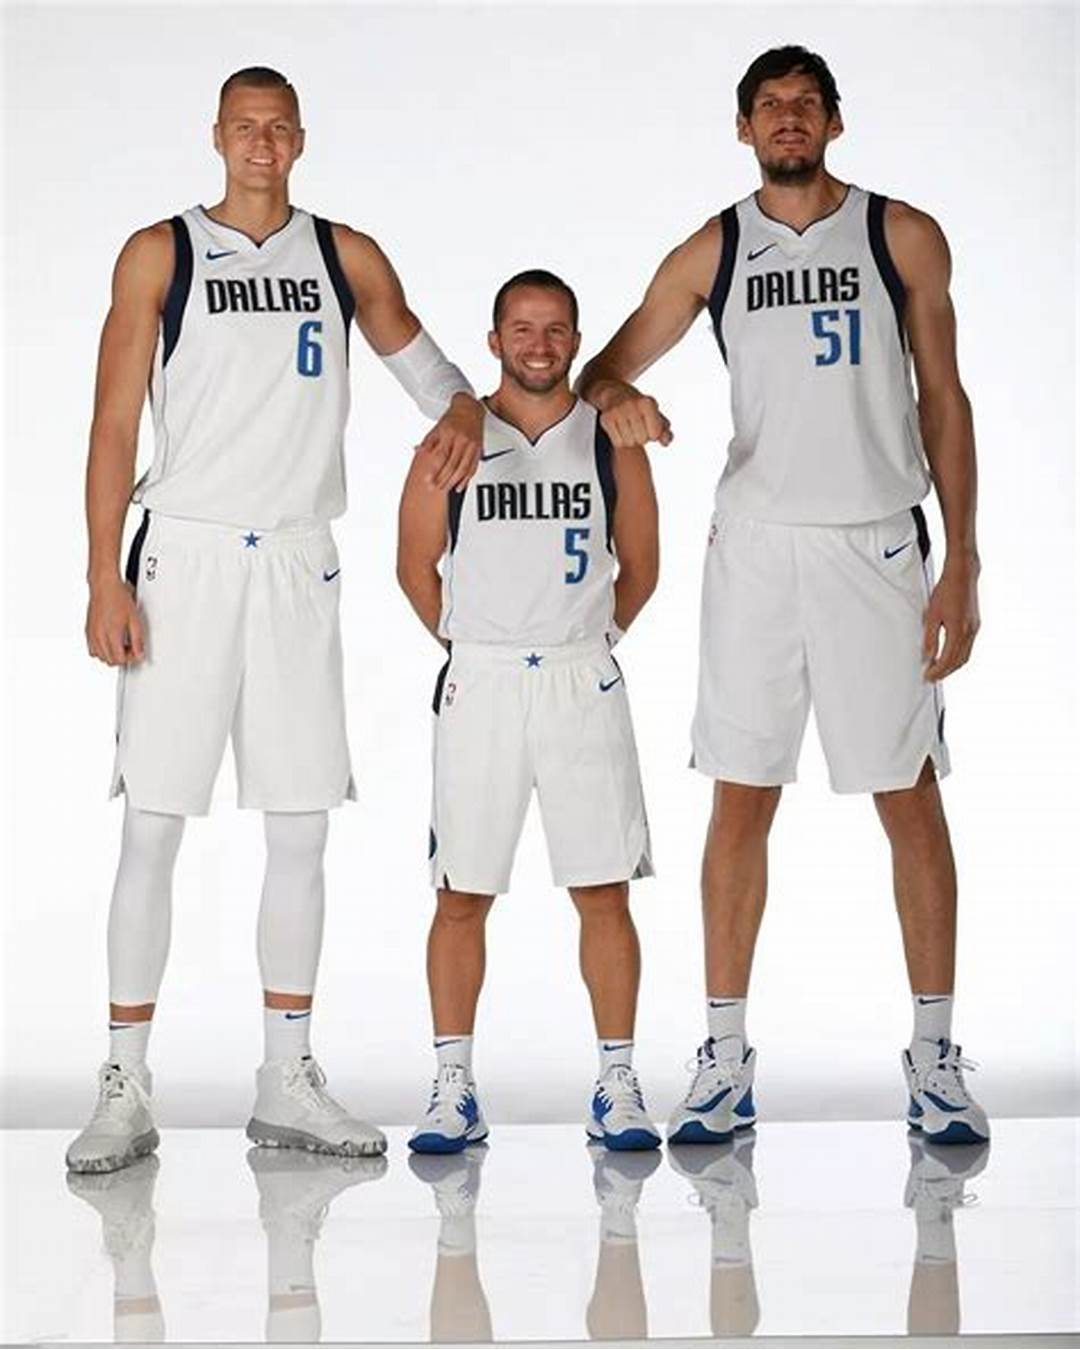


# **1. Importação de bibliotecas**

In [ ]:
import pandas as pd
import plotly.express as px
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re
import seaborn as sns

In [ ]:
# Baixa e Ler arquivo de dados
!gdown 1x3HeOKT-uNZJF4KOlpW-z2rOuL21DD-e
data = pd.read_csv('nba_stats.csv')

Downloading...
From: https://drive.google.com/uc?id=1x3HeOKT-uNZJF4KOlpW-z2rOuL21DD-e
To: /content/nba_stats.csv
100% 3.50M/3.50M [00:00<00:00, 187MB/s]


# **2. Conhecendo o dataset**

#### **2.1 Dicionário de dados das colunas do dataset**


##### **Informações Básicas**
1. **`year`**: Temporada/ano da NBA (ex: 1999-2023).  
2. **`name`**: Nome completo do jogador.  
3. **`playerId`**: ID único do jogador no banco de dados.  
4. **`playerSlug`**: Nome formatado para URLs (ex: `lebron-james`).  
5. **`positionId`**: Código numérico da posição (ex: 1 = PG, 2 = SG).  
6. **`teamId`**: ID único do time na temporada.  
7. **`status`**: Status do jogador (ex: "Ativo", "Lesionado").  
8. **`position`**: Posição em texto (ex: "Center").  

---

##### **Estatísticas de Jogo**
9. **`gamesPlayed`**: Número de jogos disputados.  
10. **`minutes`**: Minutos jogados na temporada.  
11. **`avgMinutes`**: Média de minutos por jogo.  
12. **`points`**: Total de pontos.  
13. **`avgPoints`**: Média de pontos por jogo.  
14. **`rebounds`**: Total de rebotes.  
15. **`avgRebounds`**: Média de rebotes por jogo.  
16. **`assists`**: Total de assistências.  
17. **`avgAssists`**: Média de assistências por jogo.  
18. **`steals`**: Total de roubos de bola.  
19. **`avgSteals`**: Média de roubos por jogo.  
20. **`blocks`**: Total de bloqueios.  
21. **`avgBlocks`**: Média de bloqueios por jogo.  
22. **`turnovers`**: Total de bolas perdidas.  
23. **`avgTurnovers`**: Média de bolas perdidas por jogo.  
24. **`fouls`**: Total de faltas cometidas.  
25. **`avgFouls`**: Média de faltas por jogo.  
26. **`flagrantFouls`**: Faltas flagrantes (graves).  
27. **`technicalFouls`**: Faltas técnicas.  
28. **`ejections`**: Expulsões.  

---

##### **Arremessos**
29. **`fieldGoalsMade`**: Arremessos de quadra convertidos.  
30. **`fieldGoalsAttempted`**: Arremessos de quadra tentados.  
31. **`avgFieldGoalsMade`**: Média de arremessos convertidos por jogo.  
32. **`avgFieldGoalsAttempted`**: Média de arremessos tentados por jogo.  
33. **`fieldGoalPct`**: Porcentagem de acerto em arremessos.  
34. **`threePointFieldGoalsMade`**: 3 pontos convertidos.  
35. **`threePointFieldGoalsAttempted`**: 3 pontos tentados.  
36. **`avgThreePointFieldGoalsMade`**: Média de 3 pontos convertidos por jogo.  
37. **`avgThreePointFieldGoalsAttempted`**: Média de 3 pontos tentados por jogo.  
38. **`threePointFieldGoalPct`**: Porcentagem de acerto em 3 pontos.  
39. **`freeThrowsMade`**: Lances livres convertidos.  
40. **`freeThrowsAttempted`**: Lances livres tentados.  
41. **`avgFreeThrowsMade`**: Média de lances livres convertidos por jogo.  
42. **`avgFreeThrowsAttempted`**: Média de lances livres tentados por jogo.  
43. **`freeThrowPct`**: Porcentagem de acerto em lances livres.  

---

##### **Marcadores de Desempenho**
44. **`doubleDouble`**: Jogos com duplo-duplo (ex: 10+ pontos e 10+ rebotes).  
45. **`tripleDouble`**: Jogos com triplo-duplo (ex: 10+ pontos, 10+ rebotes, 10+ assistências).  

---

##### **Informações Pessoais e Carreira**
46. **`birthdate`**: Data de nascimento.  
47. **`college`**: Universidade (se aplicável).  
48. **`draftinfo`**: Detalhes do draft (ex: ano, rodada, escolha).  
49. **`birthplace`**: Local de nascimento (cidade/país).  
50. **`team`**: Nome do time.  
51. **`htwt`**: Altura e peso (ex: `6-8, 250 lbs`).  
52. **`experience`**: Anos de experiência na NBA.  
53. **`rankingSalary`**: Posição no ranking de salários.  
54. **`salary`**: Salário anual (em dólares).  



#### **2.2 Análise de quantidade de nulos por coluna**

In [ ]:
data.isna().sum(axis=0)

,0
year,0
name,0
playerId,0
playerSlug,0
positionId,6
teamId,0
status,0
gamesPlayed,0
avgMinutes,0
avgFouls,0


#### **2.3 Análise para generalização de dados de altura**

Identificou-se 5.858 nulos na coluna de altura. Antes de elimina-los validamos a hipotese:

**Jogares que não tem altura catalogada em algum momento tiveram apenas um registro de altura em algum outro momento?**

Para saber se todos os playes que não tem registro não possuem algum ano de exceção com registro para generaliarmos a altura e ampliar a quantidade de dados.

In [ ]:
data['alturas nulas'] = data['htwt'].isna()
verificacao = data[['playerId','alturas nulas']].drop_duplicates()
verificacao['playerId'].value_counts(ascending=False)

,count
playerId,
4432356,1
4431767,1
4433623,1
4576086,1
4869342,1
...,...
3,1
897,1
242,1


Acima criamos uma nova coluna mostrando quem tem altura nula. Depois excluirmos os dados que tem 'playerId' e 'alturas nulas' duplicados, pois caso tenha alguém com altura nula constando True e Falso o playerId irá aparecer duas vezes. Como podemos ver ninguém apareceu duas vezes, apenas uma. Então vamos ter de tirar todos os dados com altura nulas.

# **3. Tratamento de dados**

#### **3.1 Deletando dados com nulos na coluna de altura**

In [ ]:
data.dropna(subset =['htwt'], inplace = True)
data.reset_index(drop = True, inplace = True)

- Percebe-se que agora só temos valores nulos nas colunas de 'college','draftinfo','birthplace', como não são colunas referente a desempenho isso não irá alterar em nossa anális em nada.

- Após a remoção dos valores nulos, ficamos apenas com 28,22% do dado total.

#### **3.2 Tratando coluna de altura**

In [ ]:
def tranformar_altura_centimetros(texto:str) -> float:
  match = re.search(r"(\d+)'\s*(\d+)\"", texto)
  if match:
      pes = int(match.group(1))
      polegadas = int(match.group(2))
      altura = pes * 30.48 + polegadas * 2.54
      return altura
  else:
      return None

data['htwt'] = data['htwt'].apply(tranformar_altura_centimetros)
data['htwt']

,htwt
0,203.20
1,203.20
2,203.20
3,203.20
4,203.20
...,...
2299,203.20
2300,203.20
2301,200.66
2302,190.50


#### **3.3 Selecionando colunas relevantes para nosso estudo**
- Como queremos saber se existe uma relação entre altura e desenpenho vamos deixar apenas as colunas que são relevantes para descobrir essa métrica, removendo as colunas de médias e deixando apenas o identificador de player as colunas de **estatisticas de jogo**, **arremeceços** e **marcadores de desempenho**.

In [ ]:
colunas_desejadas = ['playerId','gamesPlayed','minutes','points','rebounds','assists','steals','blocks','turnovers','fouls','flagrantFouls',
                     'technicalFouls','ejections','fieldGoalsMade','fieldGoalsAttempted','fieldGoalPct','threePointFieldGoalsMade','threePointFieldGoalsAttempted',
                     'threePointFieldGoalPct','freeThrowsMade','freeThrowsAttempted','freeThrowPct','doubleDouble','tripleDouble','htwt']

data_colunas = data[colunas_desejadas]

#### **3.4 Agrupando os dados**

- Por que agrupar os dados? Como podemos ver no exemplo abaixo, temos um jogador que entregou bastante coisas porém no último ano jogou praticamente nada, afeta a análise de desempenho pois é um outlier, vamos agrupar pela mediana pois ela é menos sensivel a valores distorcidos.

In [ ]:
data[['year','name','playerId','gamesPlayed', 'minutes', 'points',
    'rebounds', 'assists', 'steals',
     'blocks',  'turnovers',
    'fouls', 'flagrantFouls', 'technicalFouls', 'ejections',
    'fieldGoalsMade', 'fieldGoalsAttempted',
     'fieldGoalPct', 'threePointFieldGoalsMade',
    'threePointFieldGoalsAttempted',
    'threePointFieldGoalPct',
    'freeThrowsMade', 'freeThrowsAttempted',
    'freeThrowPct', 'doubleDouble', 'tripleDouble','htwt']].loc[data['htwt'] == data['htwt'].max()]

,year,name,playerId,gamesPlayed,minutes,points,rebounds,assists,steals,blocks,...,fieldGoalPct,threePointFieldGoalsMade,threePointFieldGoalsAttempted,threePointFieldGoalPct,freeThrowsMade,freeThrowsAttempted,freeThrowPct,doubleDouble,tripleDouble,htwt
1346,2016,Boban Marjanovic,4376,54.0,508.0,297.0,194.0,21.0,12.0,23.0,...,60.345001,0.0,0.0,0.000000,87.0,114.0,76.316002,3.0,0.0,223.52
1347,2017,Boban Marjanovic,4376,35.0,293.0,191.0,130.0,9.0,6.0,12.0,...,54.544998,0.0,0.0,0.000000,47.0,58.0,81.033997,5.0,0.0,223.52
1348,2018,Boban Marjanovic,4376,39.0,338.0,235.0,144.0,22.0,10.0,11.0,...,53.377998,0.0,0.0,0.000000,77.0,97.0,79.380997,1.0,0.0,223.52
1349,2019,Boban Marjanovic,4376,58.0,681.0,422.0,265.0,54.0,16.0,27.0,...,61.537998,4.0,10.0,40.000001,98.0,131.0,74.808998,6.0,0.0,223.52
1350,2020,Boban Marjanovic,4376,44.0,422.0,289.0,197.0,20.0,8.0,10.0,...,57.346001,4.0,17.0,23.529412,43.0,57.0,75.439003,6.0,0.0,223.52
1351,2021,Boban Marjanovic,4376,33.0,271.0,156.0,128.0,10.0,2.0,6.0,...,50.820000,1.0,8.0,12.500000,31.0,38.0,81.579002,3.0,0.0,223.52
1352,2022,Boban Marjanovic,4376,23.0,128.0,98.0,39.0,3.0,0.0,3.0,...,60.000000,1.0,4.0,25.000000,13.0,22.0,59.091000,0.0,0.0,223.52


##### 3.4.1 Agrupando pela mediana

In [ ]:
data_agrupado = data_colunas.groupby('playerId').median()
data_agrupado

,gamesPlayed,minutes,points,rebounds,assists,steals,blocks,turnovers,fouls,flagrantFouls,...,fieldGoalPct,threePointFieldGoalsMade,threePointFieldGoalsAttempted,threePointFieldGoalPct,freeThrowsMade,freeThrowsAttempted,freeThrowPct,doubleDouble,tripleDouble,htwt
playerId,,,,,,,,,,,,,,,,,,,,,
558,65.0,1964.0,722.0,286.5,184.0,37.0,15.0,107.5,138.5,0.0,...,43.798500,96.0,229.0,40.281124,96.5,134.5,75.621498,2.5,0.0,203.20
1966,76.0,2889.5,2062.5,543.5,517.5,118.5,51.0,252.5,130.5,0.0,...,50.610500,114.5,333.0,34.599264,395.5,533.0,74.416500,26.5,4.0,205.74
2184,49.0,995.0,261.0,258.0,38.0,21.0,15.0,41.0,113.0,0.0,...,49.233002,0.0,2.0,0.000000,32.0,45.0,75.000000,3.0,0.0,203.20
2373,74.0,2249.0,742.0,387.0,131.0,74.0,35.0,101.0,184.0,0.0,...,55.159000,13.0,56.0,23.214285,154.0,201.0,76.616997,6.0,0.0,203.20
2386,72.0,2139.0,672.5,342.5,258.0,98.0,35.5,107.5,102.5,0.0,...,45.913000,60.5,176.0,33.032812,103.5,164.0,67.561001,3.5,0.0,198.12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4871144,73.5,1830.0,900.5,535.5,238.0,64.5,69.0,169.0,236.0,0.0,...,51.374001,24.0,87.0,29.059830,185.5,260.0,71.324501,18.5,1.0,210.82
4871145,65.0,2033.5,967.0,510.0,407.0,54.0,25.5,191.0,115.5,0.5,...,45.075499,66.0,223.5,29.384856,81.0,112.0,71.994499,22.0,4.0,203.20
4914336,80.0,1779.0,789.0,236.0,94.0,38.0,24.0,83.0,136.0,0.0,...,47.222000,102.0,283.0,36.042404,75.0,105.0,71.429001,0.0,0.0,195.58


#### 3.5 Calculando o PER

In [ ]:
data_agrupado['PER'] = (
    (data_agrupado['points'] + data_agrupado['rebounds'] + data_agrupado['assists'] + data_agrupado['steals'] + data_agrupado['blocks']) -
    ((data_agrupado['fieldGoalsAttempted'] - data_agrupado['fieldGoalsMade']) +
     (data_agrupado['freeThrowsAttempted'] - data_agrupado['freeThrowsMade']) +
     data_agrupado['fouls'] +
     data_agrupado['turnovers'])
) / data_agrupado['minutes']

data_agrupado[['htwt','PER']].sort_values(by='PER', ascending=False).head(10)

,htwt,PER
playerId,,
3112335,210.82,0.863931
3032977,210.82,0.826173
3945274,200.66,0.781399
6583,208.28,0.778508
3136195,213.36,0.771316
4376,223.52,0.763314
3059318,213.36,0.756799
4395628,198.12,0.751046
1966,205.74,0.743727


# **4. Analisando dados de altura**

#### **4.1 Describe da coluna altura**

In [ ]:
data_agrupado['htwt'].describe(percentiles = [0.05,0.1,0.25,0.5,0.75,.9,.95])

,htwt
count,433.00000
mean,200.02060
std,8.05035
min,177.80000
5%,185.42000
10%,190.50000
25%,195.58000
50%,200.66000
75%,205.74000
90%,210.82000


#### **4.2 Distribuição da altura**
- Removemos os outlies para fazer essa análise

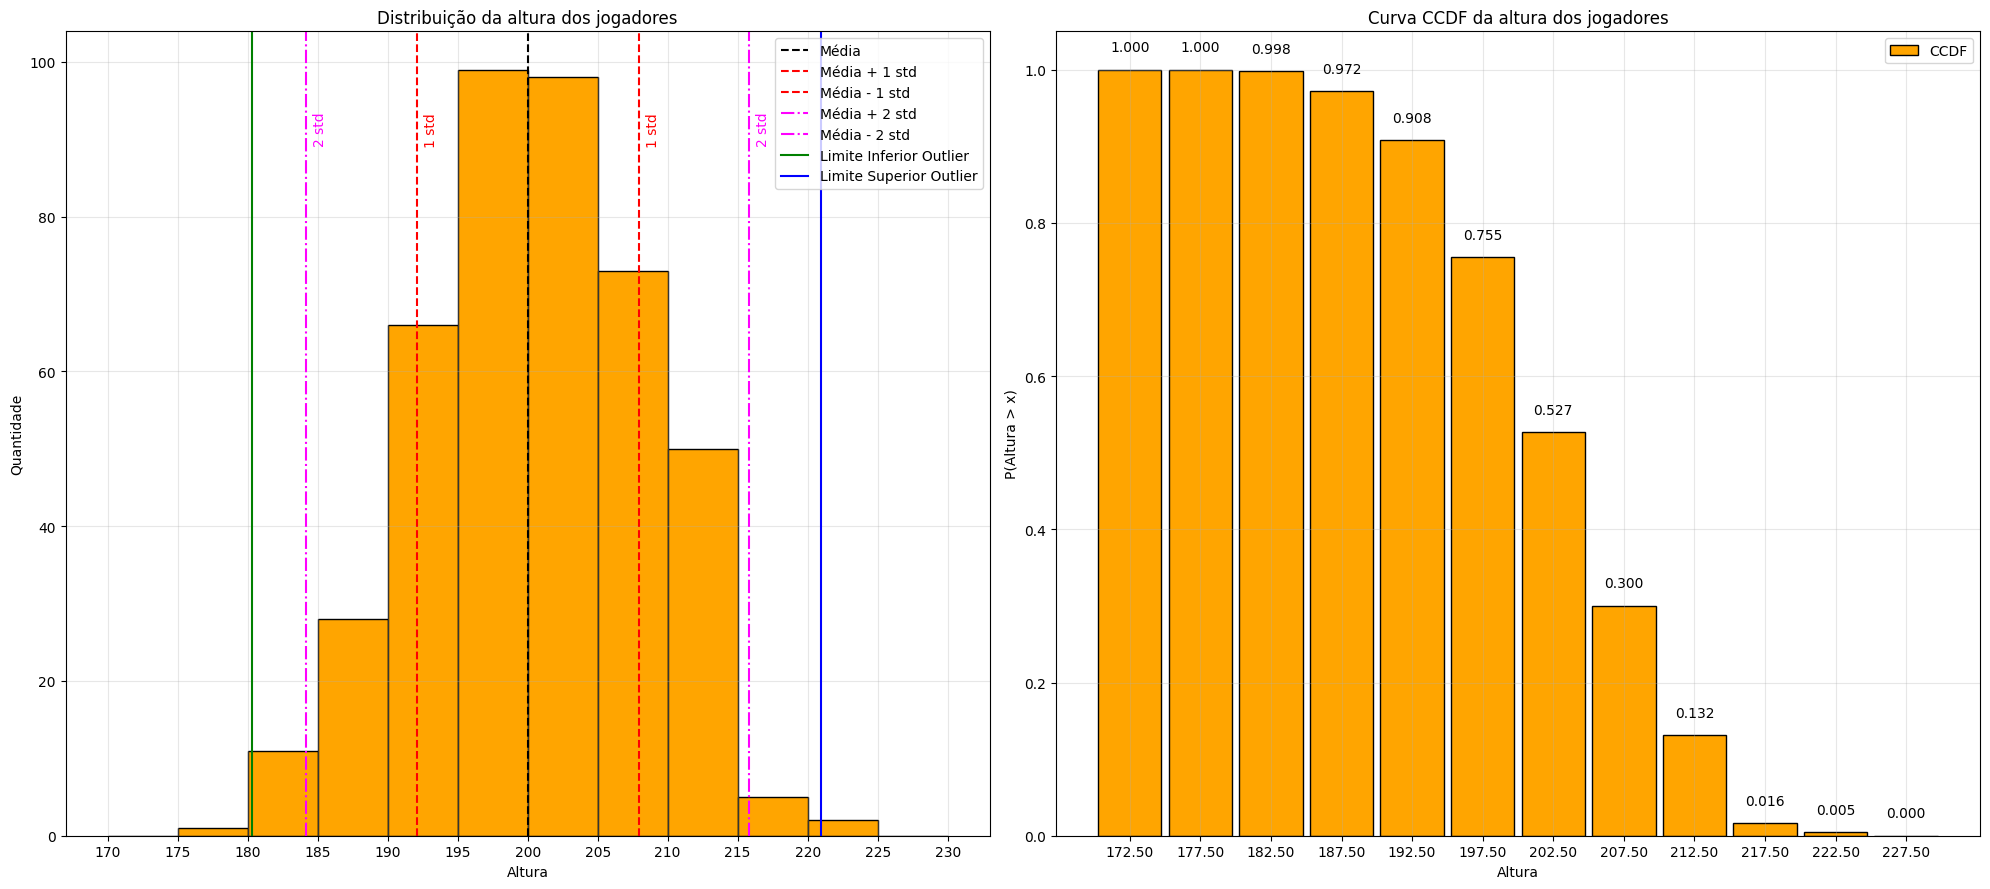

In [ ]:
# Cálculo das métricas
htwt_data = data_agrupado['htwt']
IQR = np.quantile(data_agrupado['htwt'], 0.75) - np.quantile(data_agrupado['htwt'], 0.25)
mediana = np.quantile(data_agrupado['htwt'], 0.50)
# Cálculo dos limites de outliers
Q1 = np.quantile(data_agrupado['htwt'], 0.25)
Q3 = np.quantile(data_agrupado['htwt'], 0.75)
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

# Filtrando os dados sem outliers (para métricas da média e desvios)
data_sem_outlies = htwt_data[(htwt_data >= lower_limit) & (htwt_data <= upper_limit)]
media = np.mean(data_sem_outlies)
std = np.std(data_sem_outlies)
desvio_1_sup = media + std
desvio_1_inf = media - std
desvio_2_sup = media + 2 * std
desvio_2_inf = media - 2 * std

# Define os intervalos de bin para o histograma e gráfico de barras
bins = [x for x in range(170, 231, 5)]

# Criação dos subplots: 1 linha, 2 colunas
fig, (ax_esq, ax_dir) = plt.subplots(nrows=1, ncols=2, figsize=(20, 9))

###########################
# Gráfico da Esquerda: Histograma
###########################
ax_esq.hist(data_agrupado['htwt'], edgecolor='black', color='orange', bins=bins)

# Média e desvios
ax_esq.axvline(x=media, ls='--', color='black', label='Média')
ax_esq.axvline(x=desvio_1_sup, ls='--', color='red', label='Média + 1 std')
ax_esq.axvline(x=desvio_1_inf, ls='--', color='red', label='Média - 1 std')
ax_esq.axvline(x=desvio_2_sup, ls='-.', color='magenta', label='Média + 2 std')
ax_esq.axvline(x=desvio_2_inf, ls='-.', color='magenta', label='Média - 2 std')

# Limites de outliers
ax_esq.axvline(x=lower_limit, ls='-', color='green', label='Limite Inferior Outlier')
ax_esq.axvline(x=upper_limit, ls='-', color='blue', label='Limite Superior Outlier')

ax_esq.set_xticks(bins)
ax_esq.set_title('Distribuição da altura dos jogadores')
ax_esq.set_xlabel('Altura')
ax_esq.set_ylabel('Quantidade')
ax_esq.grid(True, alpha=0.3)

# Obter limites do eixo y para posicionar as anotações
ymin, ymax = ax_esq.get_ylim()
y_pos = ymax * 0.9  # posição vertical para anotações

# Anotações para ±1 desvio padrão
ax_esq.text(desvio_1_sup + 0.5, y_pos, '1 std', color='red', rotation=90, va='top', fontsize=10)
ax_esq.text(desvio_1_inf + 0.5, y_pos, '1 std', color='red', rotation=90, va='top', fontsize=10)

# Anotações para ±2 desvios padrão
ax_esq.text(desvio_2_sup + 0.5, y_pos, '2 std', color='magenta', rotation=90, va='top', fontsize=10)
ax_esq.text(desvio_2_inf + 0.5, y_pos, '2 std', color='magenta', rotation=90, va='top', fontsize=10)

ax_esq.legend(loc='upper right')

###########################
# Gráfico da Direita: CCDF como Gráfico de Barras
###########################
# Calcula o histograma para os mesmos bins
hist_counts, bin_edges = np.histogram(data_agrupado['htwt'], bins=bins)
# Calcula a CCDF: soma cumulativa reversa dos counts e normaliza
ccdf_counts = np.cumsum(hist_counts[::-1])[::-1]
total = len(data_agrupado['htwt'])
ccdf_prob = ccdf_counts / total

# Centros dos bins para posicionar as barras e definir a largura delas
bin_centers = (np.array(bin_edges[:-1]) + np.array(bin_edges[1:])) / 2
bar_width = (bin_edges[1] - bin_edges[0]) * 0.9

bars = ax_dir.bar(bin_centers, ccdf_prob, width=bar_width, color='orange', edgecolor='black')

# Configura os xticks para que fiquem centralizados em relação aos centros dos bins
ax_dir.set_xticks(bin_centers)
ax_dir.set_xticklabels([f'{bc:.2f}' for bc in bin_centers])

# Adiciona os valores em cima de cada barra
for bc, prob in zip(bin_centers, ccdf_prob):
    ax_dir.text(bc, prob + 0.02, f'{prob:.3f}', ha='center', va='bottom', fontsize=10)

ax_dir.set_title('Curva CCDF da altura dos jogadores')
ax_dir.set_xlabel('Altura')
ax_dir.set_ylabel('P(Altura > x)')
ax_dir.grid(True, alpha=0.3)
ax_dir.legend(['CCDF'], loc='upper right')

# Ajusta o layout e exibe os gráficos
plt.tight_layout()
plt.show()

# **5. Analisando Correlação**

#### **5.1 Plotando gráfico da correlação com a altura**


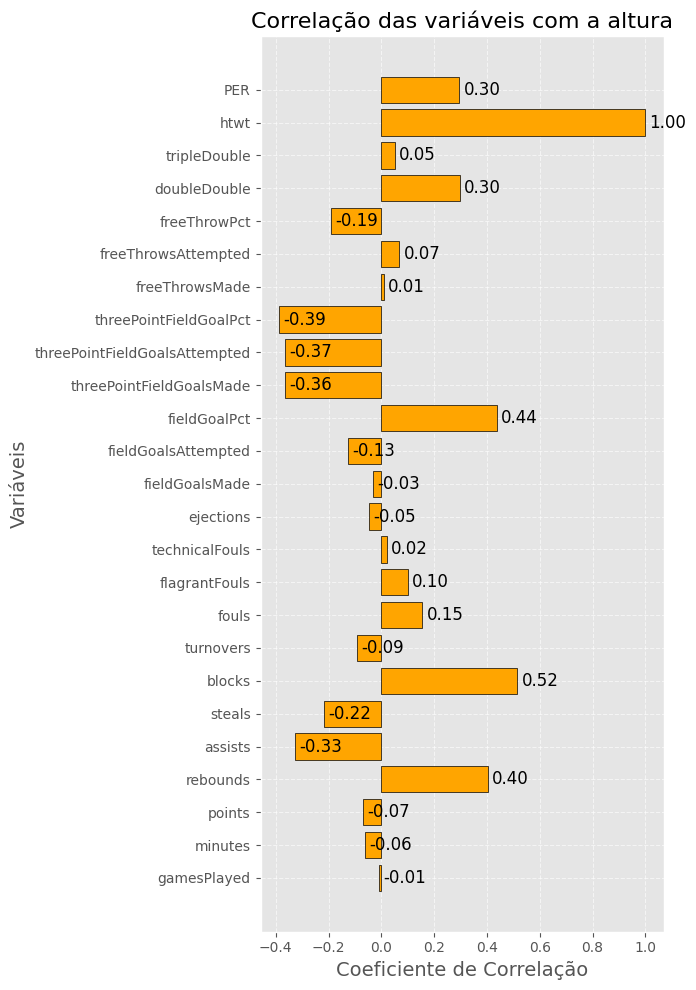

In [ ]:
# Calcula a correlação entre as variáveis e a altura (htwt)
corr_htwt = data_agrupado.corr()['htwt']

# Plotando gráfico
plt.style.use('ggplot')
fig, ax = plt.subplots(figsize=(7, 10))
bars = ax.barh(corr_htwt.index, corr_htwt.values, color='orange', edgecolor='black')
ax.set_title('Correlação das variáveis com a altura', fontsize=16)
ax.set_xlabel('Coeficiente de Correlação', fontsize=14)
ax.set_ylabel('Variáveis', fontsize=14)
ax.grid(True, linestyle='--', alpha=0.6)

for bar in bars:
    width = bar.get_width()
    ax.annotate(f'{width:.2f}',
                xy=(width, bar.get_y() + bar.get_height() / 2),
                xytext=(3, 0),
                textcoords="offset points",
                ha='left',
                va='center',
                fontsize=12)
plt.tight_layout()
plt.show()


#### **5.2 Scatter plot das principais correlações**

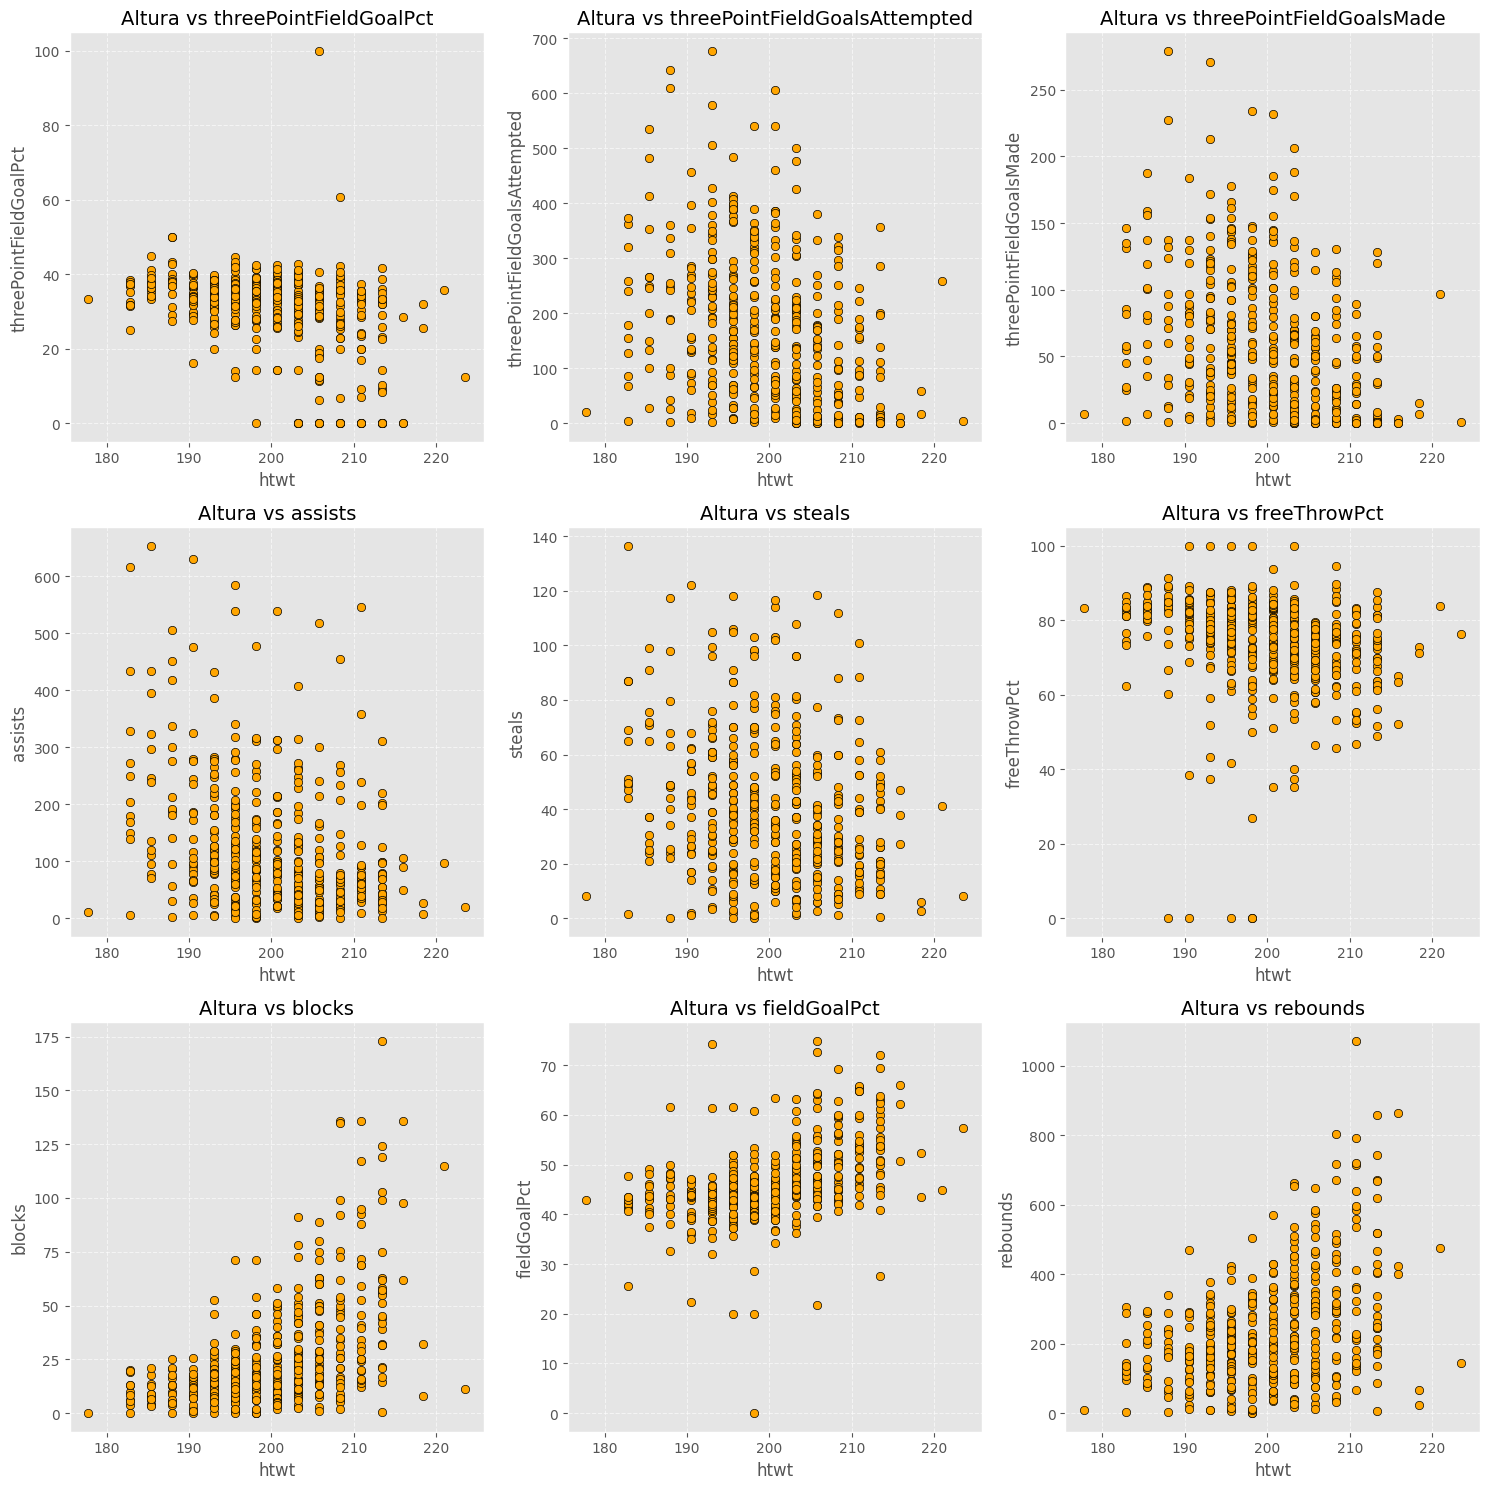

In [ ]:
# Calcula as correlações e seleciona as colunas de interesse
corr = data_agrupado.corr()['htwt'].drop('htwt')
menores_corr = corr.nsmallest(6).index.tolist()
maiores_corr = corr.nlargest(3).index.tolist()
colunas_plot = menores_corr + maiores_corr

# Cria uma grid 3x3 com estilo ggplot e plotagem dos scatter plots
plt.style.use('ggplot')
fig, axes = plt.subplots(3, 3, figsize=(15, 15))
axes = axes.flatten()

for i, coluna in enumerate(colunas_plot):
    axes[i].scatter(data_agrupado['htwt'], data_agrupado[coluna], color='orange', edgecolor='black')
    axes[i].set_xlabel('htwt', fontsize=12)
    axes[i].set_ylabel(coluna, fontsize=12)
    axes[i].set_title(f'Altura vs {coluna}', fontsize=14)
    axes[i].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# **6. Análise estratificado por posição**

#### **6.1 Fazendo a separação por posição**

In [ ]:
colunas_desejadas = [
    'playerId','position','gamesPlayed', 'minutes', 'points',
    'rebounds', 'assists', 'steals',
     'blocks',  'turnovers',
    'fouls', 'flagrantFouls', 'technicalFouls', 'ejections',
    'fieldGoalsMade', 'fieldGoalsAttempted',
     'fieldGoalPct', 'threePointFieldGoalsMade',
    'threePointFieldGoalsAttempted',
    'threePointFieldGoalPct',
    'freeThrowsMade', 'freeThrowsAttempted',
    'freeThrowPct', 'doubleDouble', 'tripleDouble','htwt'
]
data_position = data[colunas_desejadas]

data_estratificado = data_position.groupby(['position','playerId']).median()
data_estratificado['PER'] = (
    (data_estratificado['points'] + data_estratificado['rebounds'] + data_estratificado['assists'] + data_estratificado['steals'] + data_estratificado['blocks']) -
    ((data_estratificado['fieldGoalsAttempted'] - data_estratificado['fieldGoalsMade']) +
     (data_estratificado['freeThrowsAttempted'] - data_estratificado['freeThrowsMade']) +
     data_estratificado['turnovers'])
) / data_estratificado['minutes']

data_estratificado

gamesPlayed  minutes  points  rebounds  assists  \
position      playerId                                                    
Center        2990             62.0    995.0   258.0     258.0     31.0   
              3213             69.0   2242.0   925.0     531.0    240.0   
              3442             73.5   2028.5   645.0     584.5     67.5   
              3447             66.5   1480.0   604.0     279.0     55.0   
              3448             74.0   2222.0  1068.0     403.0     98.0   
...                             ...      ...     ...       ...      ...   
Small Forward 4433134          75.5   2647.5  1156.5     534.5    313.5   
              4566434          79.5   2519.0  1341.0     342.5    257.0   
              4594327          80.0   2382.0   976.0     371.0     98.0   
              4683021          76.0   1984.0   685.0     425.0    167.0   
              4701230          46.0    581.0   223.5     154.0     43.0   

                        steals  blocks  turnovers  fouls  flagrantFouls  ...  \
position      playerId                                                   ...   
Center        2990        22.0    48.0       33.0  106.0            0.0  ...   
              3213        53.0    80.0      103.0  138.0            0.0  ...   
              3442        40.0    92.5      100.5  190.5            0.0  ...   
              3447        15.5    56.5       74.0  123.0            1.0  ...   
              3448        43.0   124.0      104.0  192.0            0.0  ...   
...                        ...     ...        ...    ...            ...  ...   
Small Forward 4433134     81.5    58.0      145.0  181.0            1.0  ...   
              4566434     72.5    25.5      143.0  173.5            0.5  ...   
              4594327     61.0    42.0       60.0  162.0            1.0  ...   
              4683021     59.0    29.0       87.0  190.0            0.0  ...   
              4701230     20.5    18.0       25.0   61.0            0.0  ...   

                        threePointFieldGoalsMade  \
position      playerId                             
Center        2990                           0.0   
              3213                          56.0   
              3442                           0.0   
              3447                           0.0   
              3448                           2.0   
...                                          ...   
Small Forward 4433134                       60.5   
              4566434                      113.0   
              4594327                      206.0   
              4683021                       69.0   
              4701230                       16.5   

                        threePointFieldGoalsAttempted  threePointFieldGoalPct  \
position      playerId                                                          
Center        2990                                0.0                0.000000   
              3213                              152.0               35.960591   
              3442                                0.5                0.000000   
              3447                                1.0                0.000000   
              3448                               14.0               14.285715   
...                                               ...                     ...   
Small Forward 4433134                           208.5               29.088406   
              4566434                           315.5               35.767733   
              4594327                           501.0               41.117764   
              4683021                           232.0               31.547618   
              4701230                            58.5               25.961538   

                        freeThrowsMade  freeThrowsAttempted  freeThrowPct  \
position      playerId                                                      
Center        2990                56.0                103.0     45.622002   
              3213               103.0       

#### **6.2 Distribuição da altura por posição**

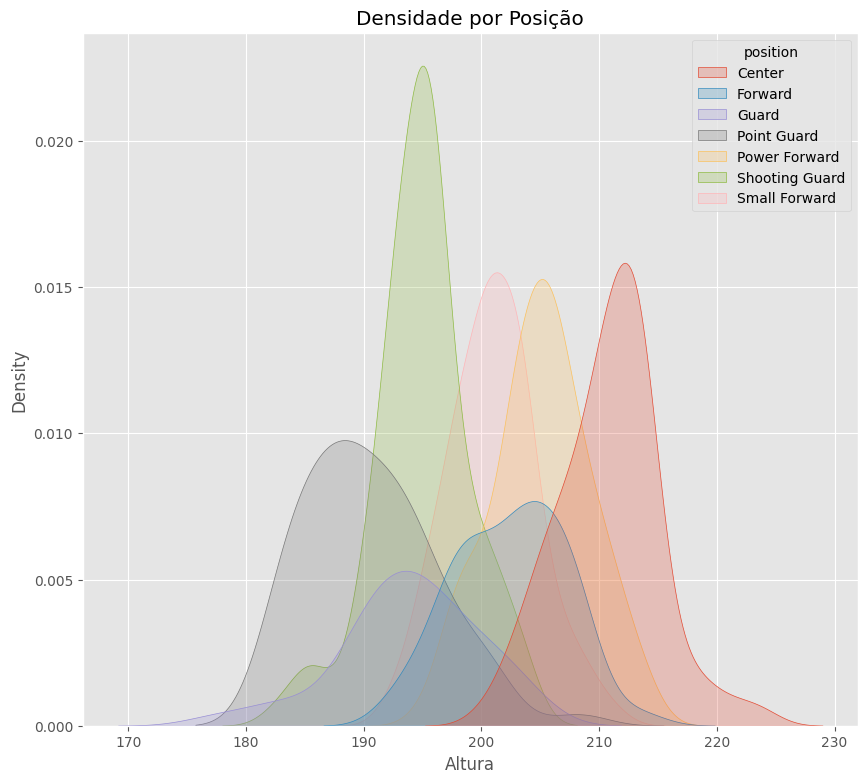

In [ ]:
plt.figure(figsize = (10,9))
sns.kdeplot(data=data_estratificado, x='htwt', hue='position', fill=True)
plt.title("Densidade por Posição")
plt.xlabel("Altura")
plt.show()

#### **6.3 Avaliando média de pontos, rebotes e assistências por posição**

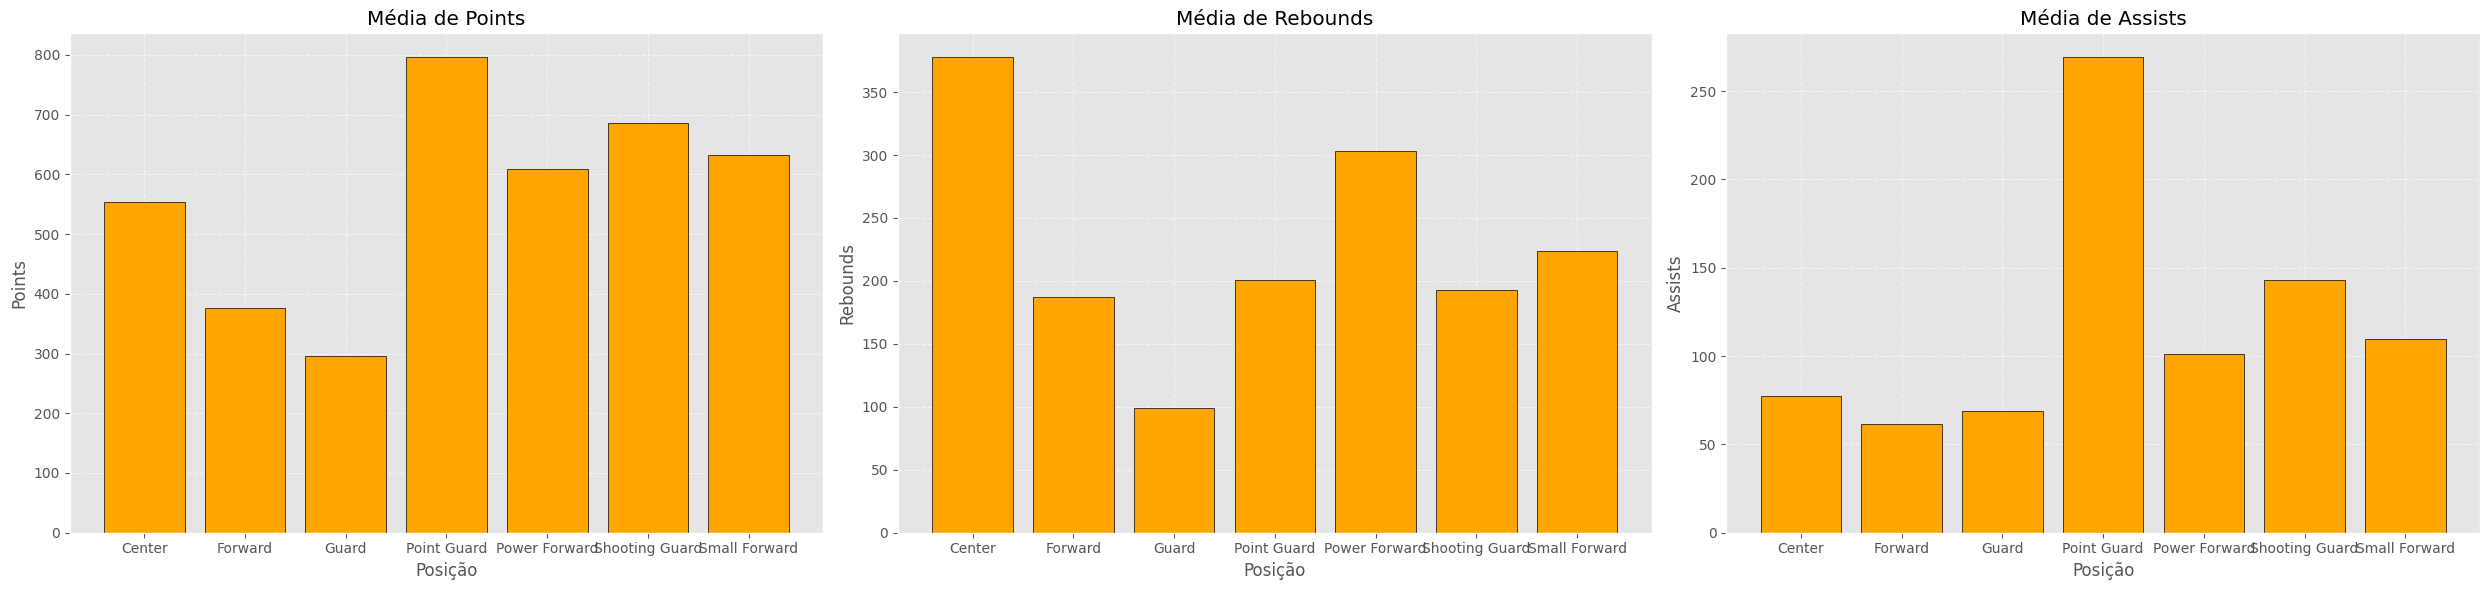

In [ ]:
# Visualização: Média de pontos, rebotes e assistências por posição
metricas = ['points', 'rebounds', 'assists']
fig, axes = plt.subplots(1, 3, figsize=(25, 6))
for i, metrica in enumerate(metricas):
    media_por_pos = data_estratificado.groupby('position')[metrica].mean().round(2)
    axes[i].bar(media_por_pos.index, media_por_pos.values, color='orange', edgecolor='black')
    axes[i].set_title(f'Média de {metrica.capitalize()}')
    axes[i].set_xlabel('Posição')
    axes[i].set_ylabel(metrica.capitalize())
    axes[i].grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

#### **6.4 Análise com Box plot por posição**

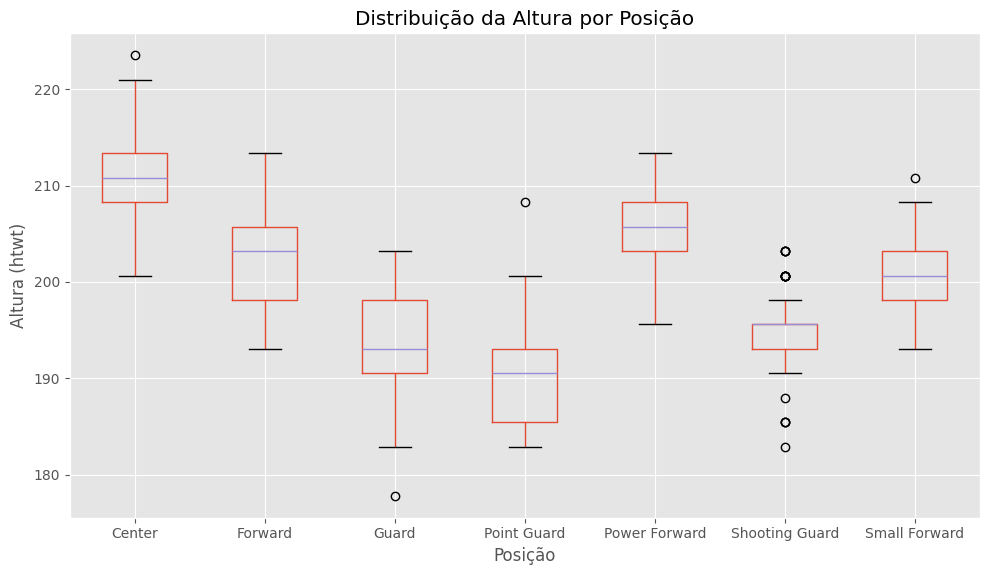

In [ ]:
plt.style.use('ggplot')
fig, ax = plt.subplots(figsize=(10, 6))
data_estratificado.boxplot(column='htwt', by='position', ax=ax)
ax.set_title('Distribuição da Altura por Posição')
ax.set_xlabel('Posição')
ax.set_ylabel('Altura (htwt)')
plt.suptitle('')
plt.tight_layout()
plt.show()

#### **6.5 Correlação por posição**

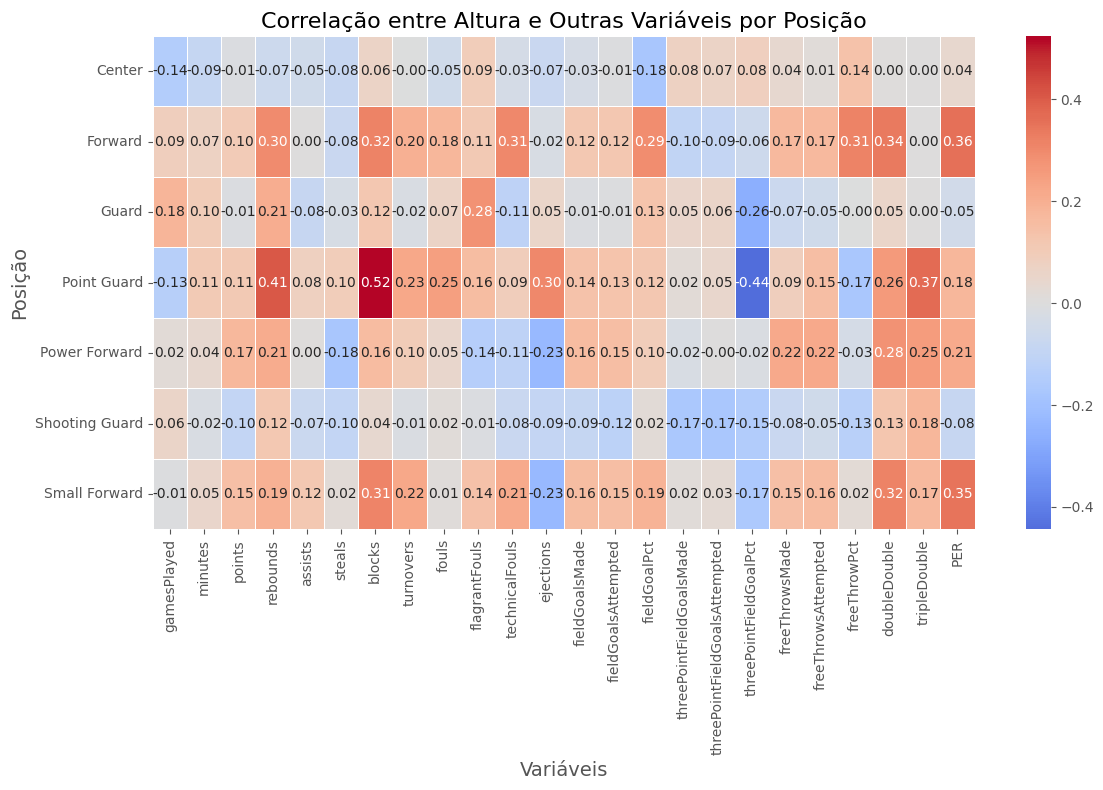

In [ ]:
# Calcula a correlação entre 'htwt' e as demais variáveis para cada posição e organiza em um DataFrame
corr_by_pos = pd.DataFrame({
    pos: grupo.corr()['htwt'].drop('htwt')
    for pos, grupo in data_estratificado.groupby('position')
}).T
corr_by_pos.fillna(0,inplace = True)

# Configura o estilo do plot
plt.style.use('ggplot')
plt.figure(figsize=(12, 8))

# Cria um heatmap com anotações para facilitar a visualização dos valores de correlação
sns.heatmap(corr_by_pos, annot=True, cmap='coolwarm', center=0, fmt=".2f", linewidths=0.5)

plt.title("Correlação entre Altura e Outras Variáveis por Posição", fontsize=16)
plt.xlabel("Variáveis", fontsize=14)
plt.ylabel("Posição", fontsize=14)
plt.tight_layout()
plt.show()

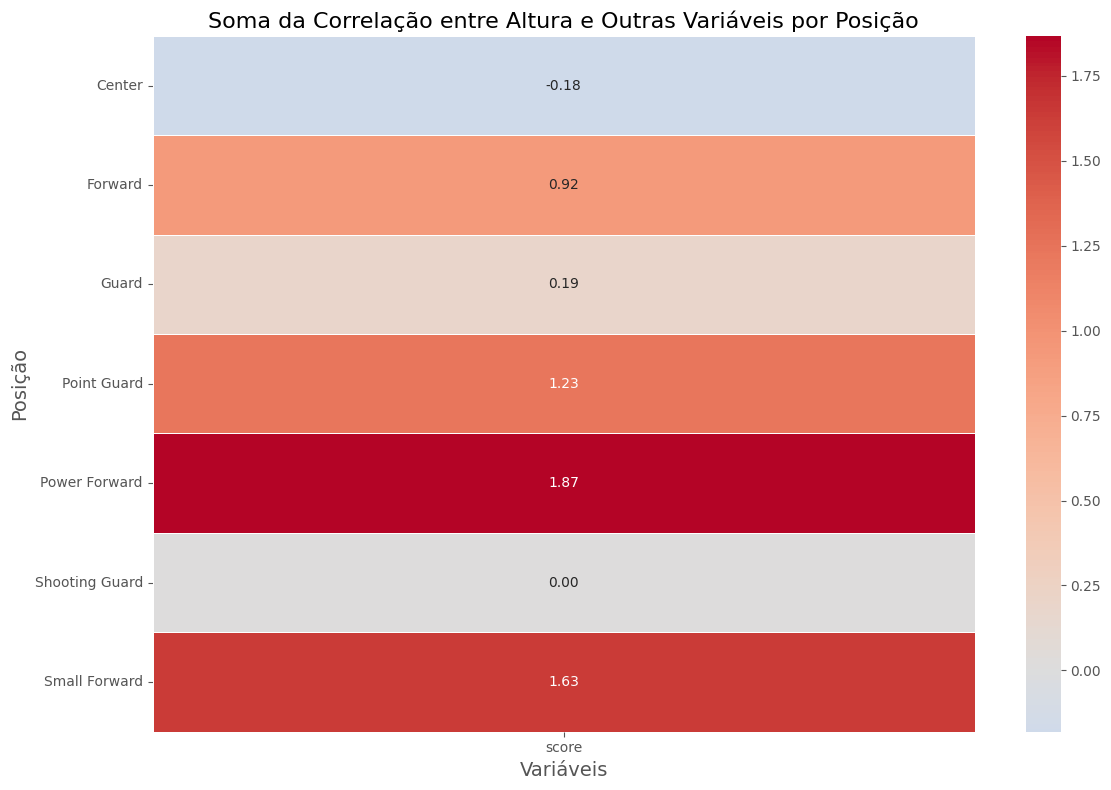

In [ ]:
colunas_positivas = [
    'gamesPlayed', 'minutes', 'points', 'rebounds', 'assists',
    'steals', 'blocks', 'fieldGoalsMade', 'threePointFieldGoalsMade',
    'freeThrowsMade', 'doubleDouble', 'tripleDouble','PER'
]
colunas_negativas = [
    'turnovers', 'fouls', 'flagrantFouls', 'technicalFouls', 'ejections'
]

# Calculando o score para cada jogador
# A soma dos valores positivos subtrai a soma dos valores negativos
corr_by_pos['score'] = (corr_by_pos[colunas_positivas].sum(axis=1) - corr_by_pos[colunas_negativas].sum(axis=1))
# corr_by_pos['score'] = corr_by_pos['score'] /corr_by_pos.shape[1])
# corr_by_pos['Soma Correlações'] = corr_by_pos['Soma Correlações'] /corr_by_pos['Soma Correlações'].max()
# Configura o estilo do plot
plt.style.use('ggplot')
plt.figure(figsize=(12, 8))

# Cria um heatmap com an[otações para facilitar a visualização dos valores de correlação
sns.heatmap(corr_by_pos[['score']], annot=True, cmap='coolwarm', center=0, fmt=".2f", linewidths=0.5)

plt.title("Soma da Correlação entre Altura e Outras Variáveis por Posição", fontsize=16)
plt.xlabel("Variáveis", fontsize=14)
plt.ylabel("Posição", fontsize=14)
plt.tight_layout()
plt.show()


# **7. CONCLUSÃO FINAL**

Após tudo o que foi exposto, a resposta curta é: SIM, PRINCIPALMENTE EM ALGUMAS POSIÇÕES. <br><br>

Pontos Relevantes sobre gráficos apresentados:<br><br>

**5.2 Scatter plot das principais correlações**
Em "Altura vs threePointFieldGoalPct", vemos que a precisão em arremessos de três pontos não se relaciona diretamente com a altura, pois há grande variação.<br><br>

**6.2  Distribuição da altura por posição**
Os “Centers” e “Power Forwards”, com médias de alturas mais expressivas são mais altos que “Point Guards” e “Shooting Guards” <br><br>

**6.3 Avaliando média de pontos, rebotes e assistências por posição**
A média dos rebotes destaca que “Centers” se destacam, pode-se entender que aqui a altura é vantajosa para rebotes e bloqueios.<br><br>

**6.4 Análise com Box plot por posição**
Percebemos uma menor variação de altura em “Centers” e posições como “Small Forward” apresentam uma dispersão maior. <br><br>

**6.5 Correlação por posição**
Vemos que para o “Point Guards”, a altura é relevante, sendo positiva para assistências (0,37) por exemplo e negativa para roubos de bola (-0,44).Podemos ver uma vantagem e uma desvantagem da altura nessa ponto




